In [112]:
%load_ext autoreload
%autoreload 2

import numpy as np
import h5py
import matplotlib.pyplot as plt
from os.path import join, exists
import os
import matplotlib as mpl
mpl.style.use('style.mcstyle')

# os.chdir('/home/x-mho1/git/ltu-cmass-run')

from astropy.cosmology import Planck18 as cosmo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'

In [114]:
# Baseline
nbody = 'quijotelike'
sim = 'fastpm_4k'
tracer = 'galaxy'
postfix = 'kmin-0.0_kmax-0.4'
summlist = ['nbar', 'zPk0', 'zPk2', 'zPk4', 'zBk0']
summaries = '+'.join(summlist)
modeldir = join(wdir, nbody, sim, 'models', tracer, summaries, postfix)
print(modeldir)

nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1]

/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_4k/models/galaxy/nbar+zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4


/tmp/ipykernel_2635216/1160103107.py:14: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_optimization_history(study, error_bar=True)
[W 2026-03-10 17:18:37,599] Your study contains infeasible trials. In optimization history plot, error bars are calculated for only feasible trial values.


Study name: nbar+zPk0+zPk2+zPk4+zBk0
Number of trials: 237


/tmp/ipykernel_2635216/1160103107.py:15: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_param_importances(study)
/tmp/ipykernel_2635216/1160103107.py:16: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  vis.plot_slice(study)
/home/x-mho1/.conda/envs/2024.02-py311/cmassrun/lib/python3.10/site-packages/optuna/visualization/matplotlib/_slice.py:146: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim[0], xlim[1])


array([<Axes: xlabel='fcn_depth', ylabel='Objective Value'>,
       <Axes: xlabel='fcn_width'>, <Axes: xlabel='hidden_features'>,
       <Axes: xlabel='learning_rate'>, <Axes: xlabel='log2_batch_size'>,
       <Axes: xlabel='lr_decay_factor'>, <Axes: xlabel='lr_patience'>,
       <Axes: xlabel='model'>, <Axes: xlabel='num_transforms'>,
       <Axes: xlabel='weight_decay'>], dtype=object)

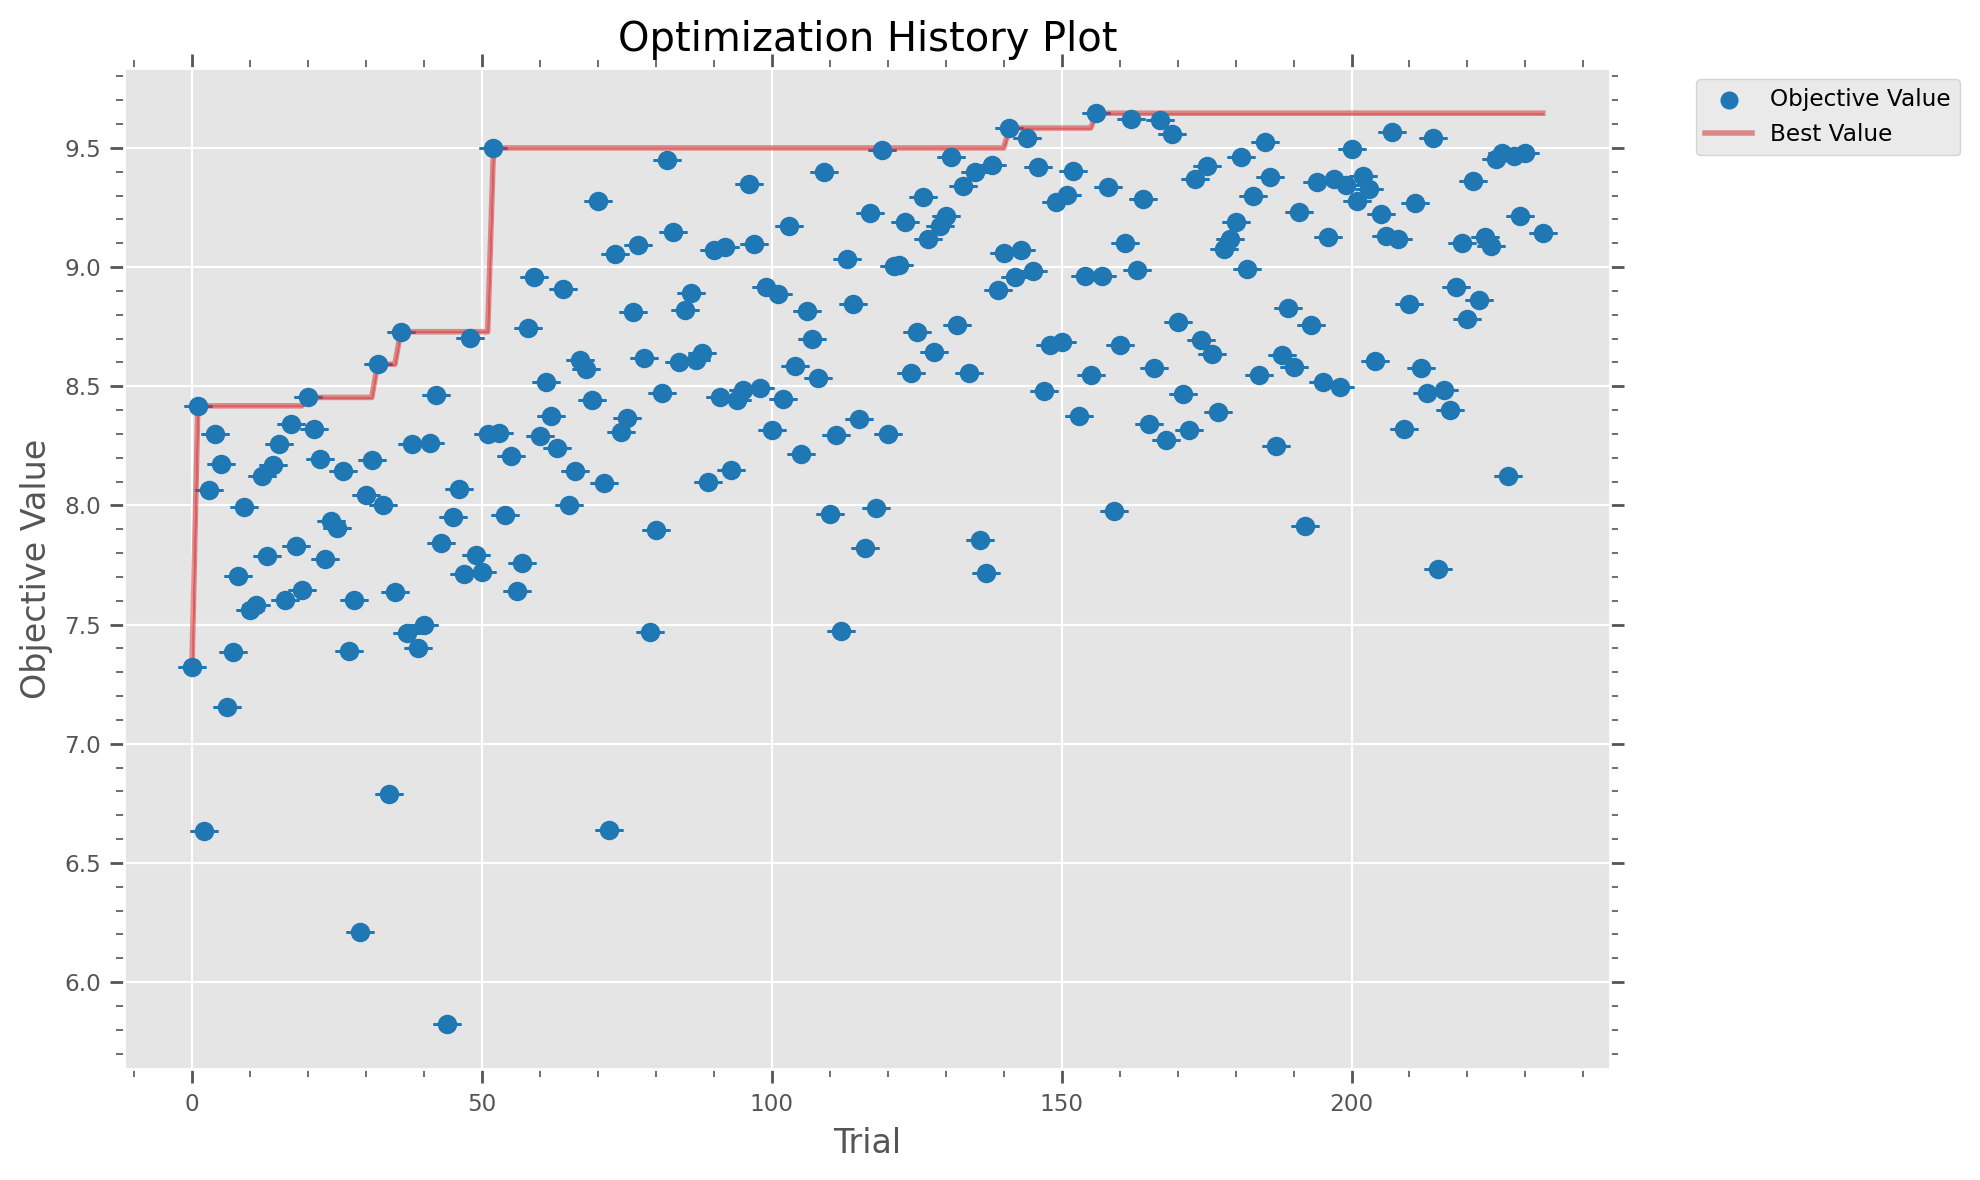

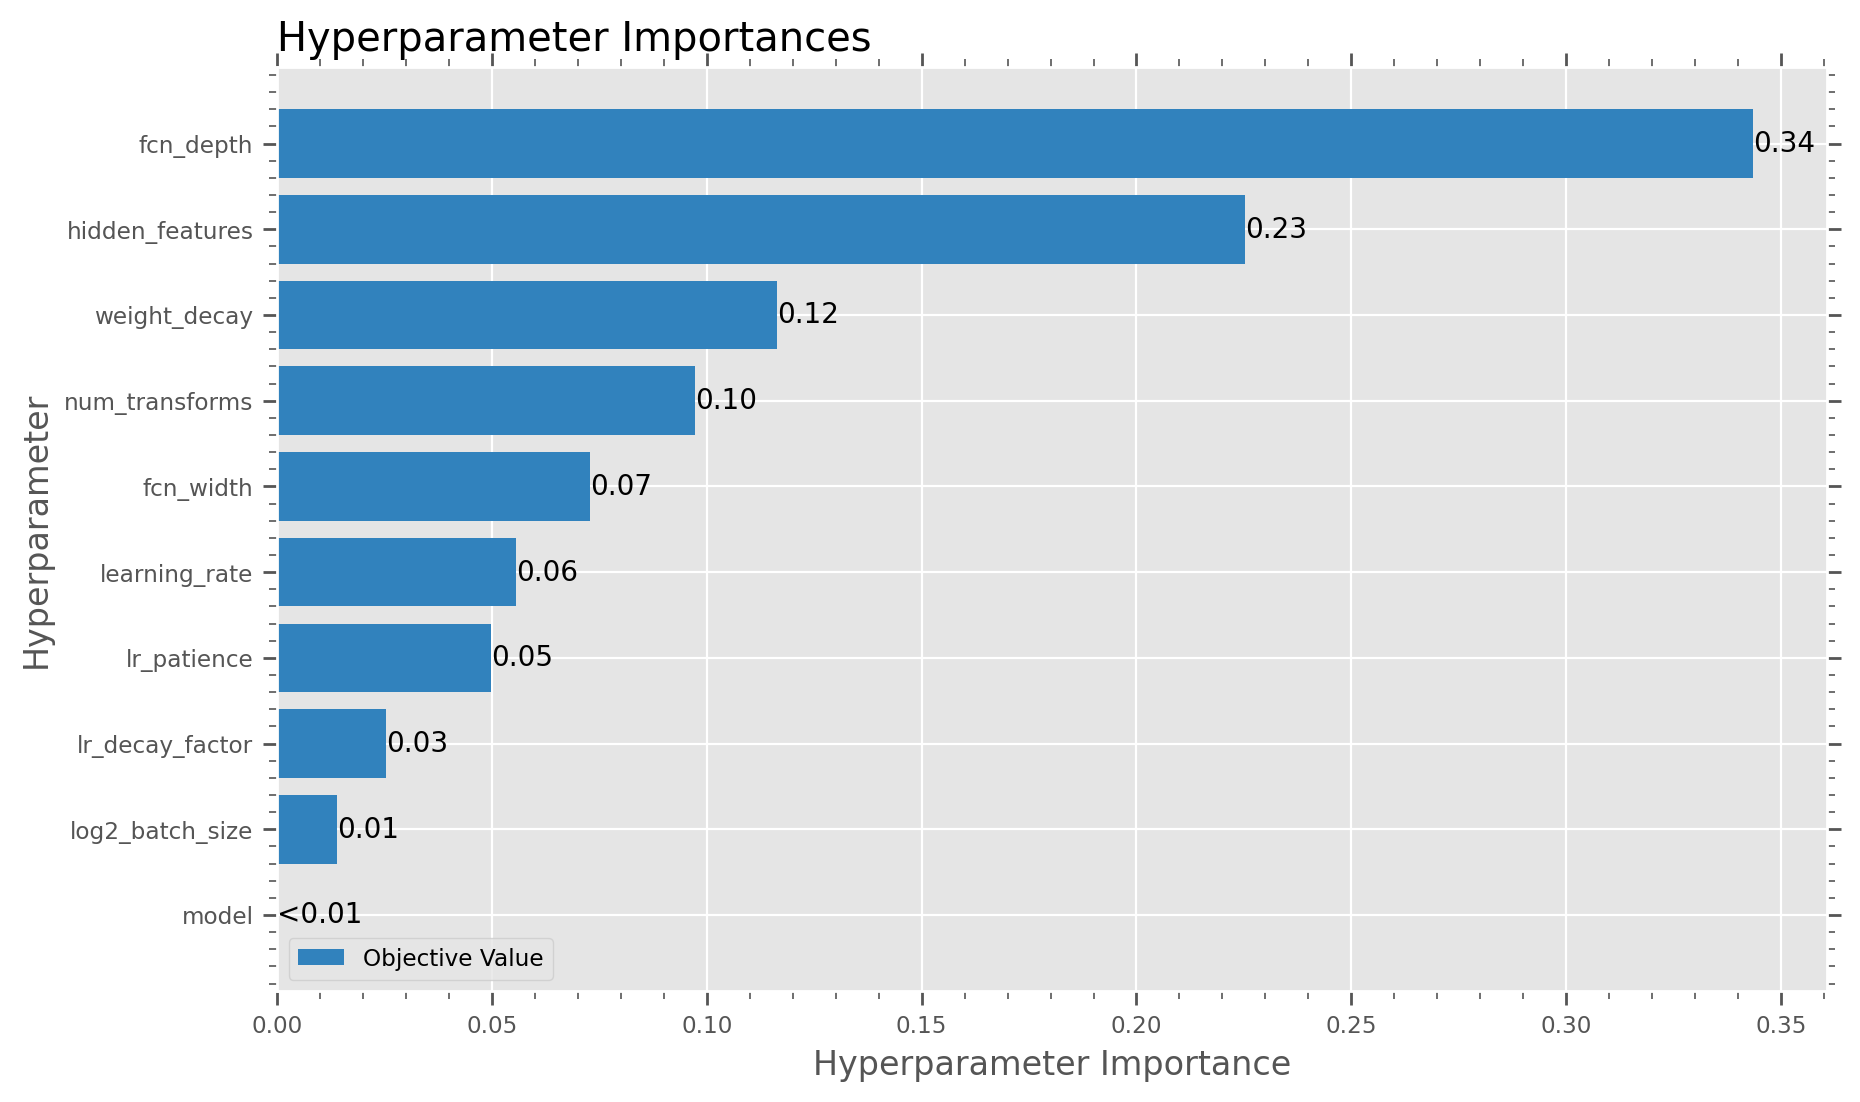

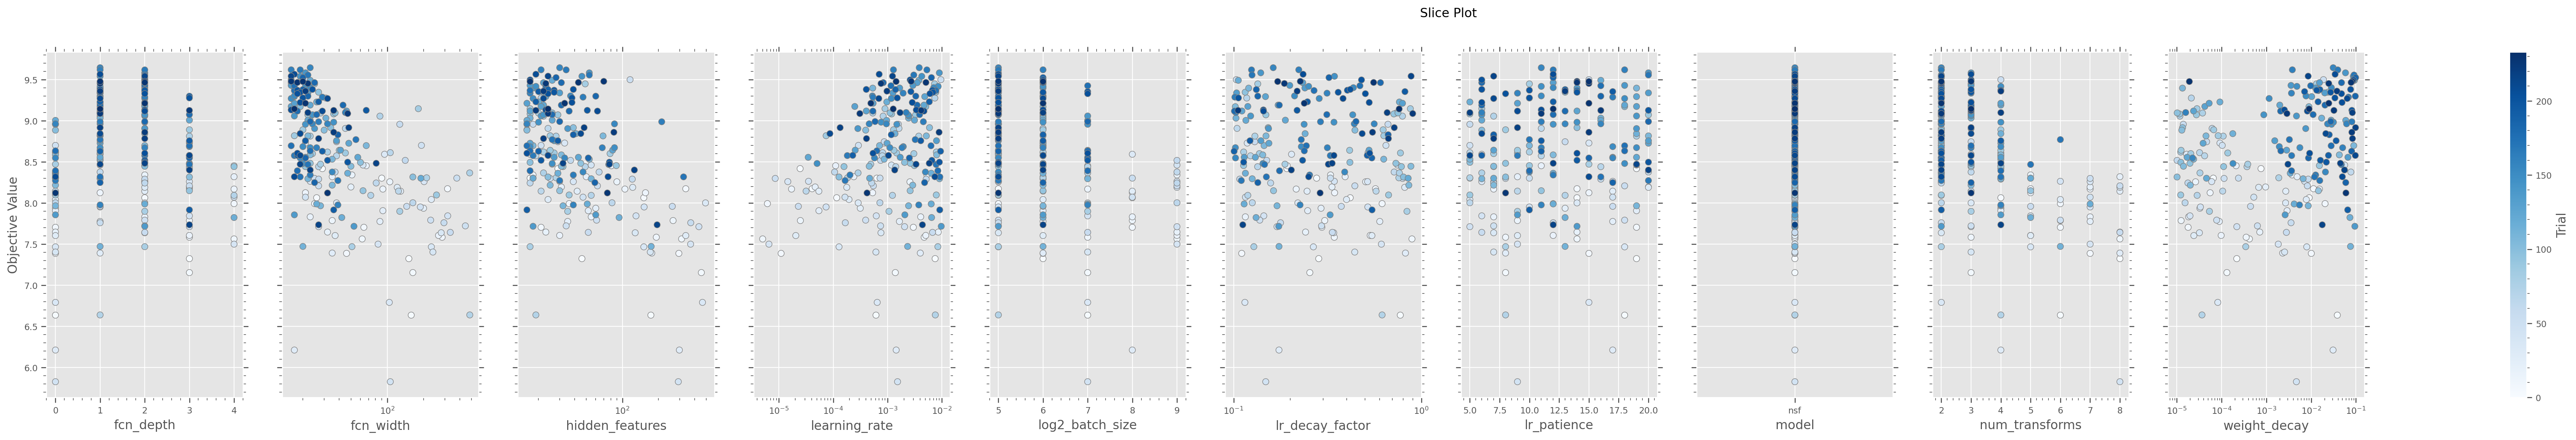

In [115]:
import optuna
import optuna.visualization.matplotlib as vis

filepath = join(modeldir, 'optuna_study.db')

# Load the 'summaries' study from the database
storage = f"sqlite:///{filepath}"
study = optuna.load_study(study_name=summaries, storage=storage)

# Print the study details
print(f"Study name: {study.study_name}")
print(f"Number of trials: {len(study.trials)}")

vis.plot_optimization_history(study, error_bar=True)
vis.plot_param_importances(study)
vis.plot_slice(study)

In [116]:
parentdir = join(wdir, nbody, sim, 'models', tracer)

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])

stdev = {}
studies = []
for s in os.listdir(parentdir):
    print(s)
    modeldir = join(parentdir, s, postfix)
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        print('Missing samples. Skipping...')
        continue
    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))

    # Find indices where theta[:, :5] is close to thetafid
    mask = np.all(np.isclose(
        theta[:, [0, 4]], thetafid[[0, 4]], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    print(f'Found {np.sum(mask)} samples close to fiducial')

    # Keep only those samples
    samples = samples[:, mask]

    stdev[s] = np.std(samples, axis=0)


    filepath = join(modeldir, 'optuna_study.db')

    # Load the 'summaries' study from the database
    storage = f"sqlite:///{filepath}"
    study = optuna.load_study(study_name=s, storage=storage)
    studies.append(study)

nbar+zPk0+zPk2+zPk4+zBk0
Found 44 samples close to fiducial
nbar+zPk0+zPk2+zPk4
Found 44 samples close to fiducial
nbar+zPk0
Found 44 samples close to fiducial


In [117]:
def simple(label):
    if isinstance(label, list):
        return [simple(l) for l in label]
    label = label.replace('nbar', r'$\bar{n}$')
    label = label.replace('zPk0+zPk2+zPk4', r'$zP_{0,2,4}$')
    label = label.replace('zPk0', r'$zP_{0}$')
    label = label.replace('zBk0', r'$zB_{0}$')
    label = label.replace('zQk0', r'$zQ_{0}$')
    label = label.replace('+', ', ')

    return label

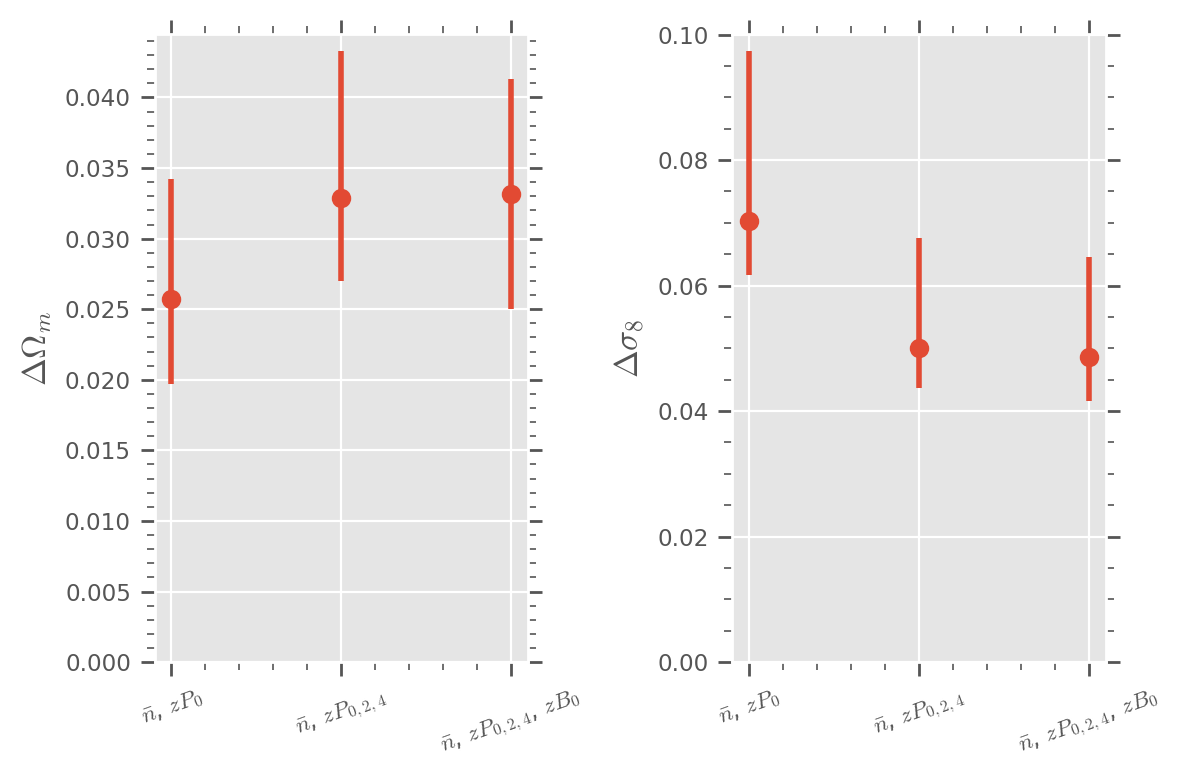

In [118]:
labels = sorted(list(stdev.keys()))

f, axs = plt.subplots(1,2, figsize=(6,4), sharex=True)
axs = axs.flatten()

names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

for j, i in enumerate([0, 4]):
    ax = axs[j]
    stdevs = [stdev[label][:, i] for label in labels]
    percentiles = np.percentile(stdevs, [50, 16, 84], axis=1)
    ax.errorbar(
        simple(labels), percentiles[0],
        yerr=[percentiles[0]-percentiles[1], percentiles[2]-percentiles[0]],
        fmt='o')
    ax.set_ylim(0)
    ax.set_ylabel(f'$\Delta {names[i]}$')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(simple(labels), rotation=20)

# axs[5].axis('off')
# axs[0].set_title('w/ BFast Bispectrum')
plt.tight_layout()

In [119]:
modeldirs = [
    '/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_4k/models/galaxy/nbar+zPk0/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_4k/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
    '/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_4k/models/galaxy/nbar+zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4',
]

names = [
    m.split('/')[-2] for m in modeldirs
]

x_len = []
for m in modeldirs:
    x_ = np.load(join(m, 'x_test.npy'))
    x_len.append(x_.shape[-1])

Text(0.5, 1.0, 'Fastpm+CHARM')

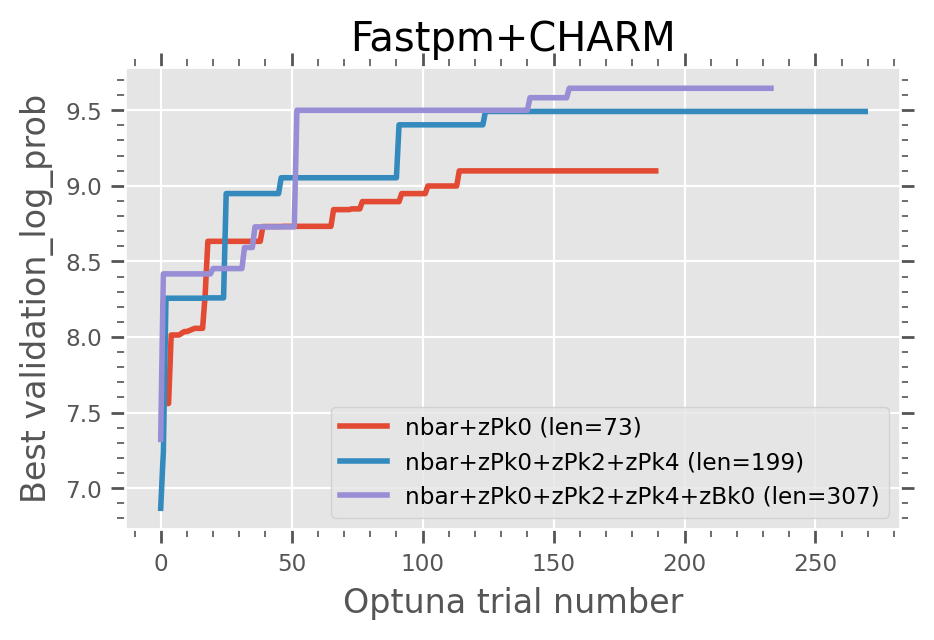

In [121]:

def plot_history(modeldir, ax, **kwargs):
    storage = f"sqlite:///{modeldir}/optuna_study.db"
    study = optuna.load_study(study_name=modeldir.split('/')[-2], storage=storage)
    trials = study.trials
    trial_numbers = [t.number for t in trials if t.value is not None]
    values = [t.value for t in trials if t.value is not None]
    
    best_values = np.maximum.accumulate(values)
    
    ax.plot(trial_numbers, best_values, **kwargs)

f, ax = plt.subplots(figsize=(5, 3))
for i, m in enumerate(modeldirs):
    plot_history(m, ax, label=f"{names[i]} (len={x_len[i]})")

ax.legend()
ax.set(xlabel='Optuna trial number', ylabel='Best validation_log_prob')
ax.set_title('Fastpm+CHARM')

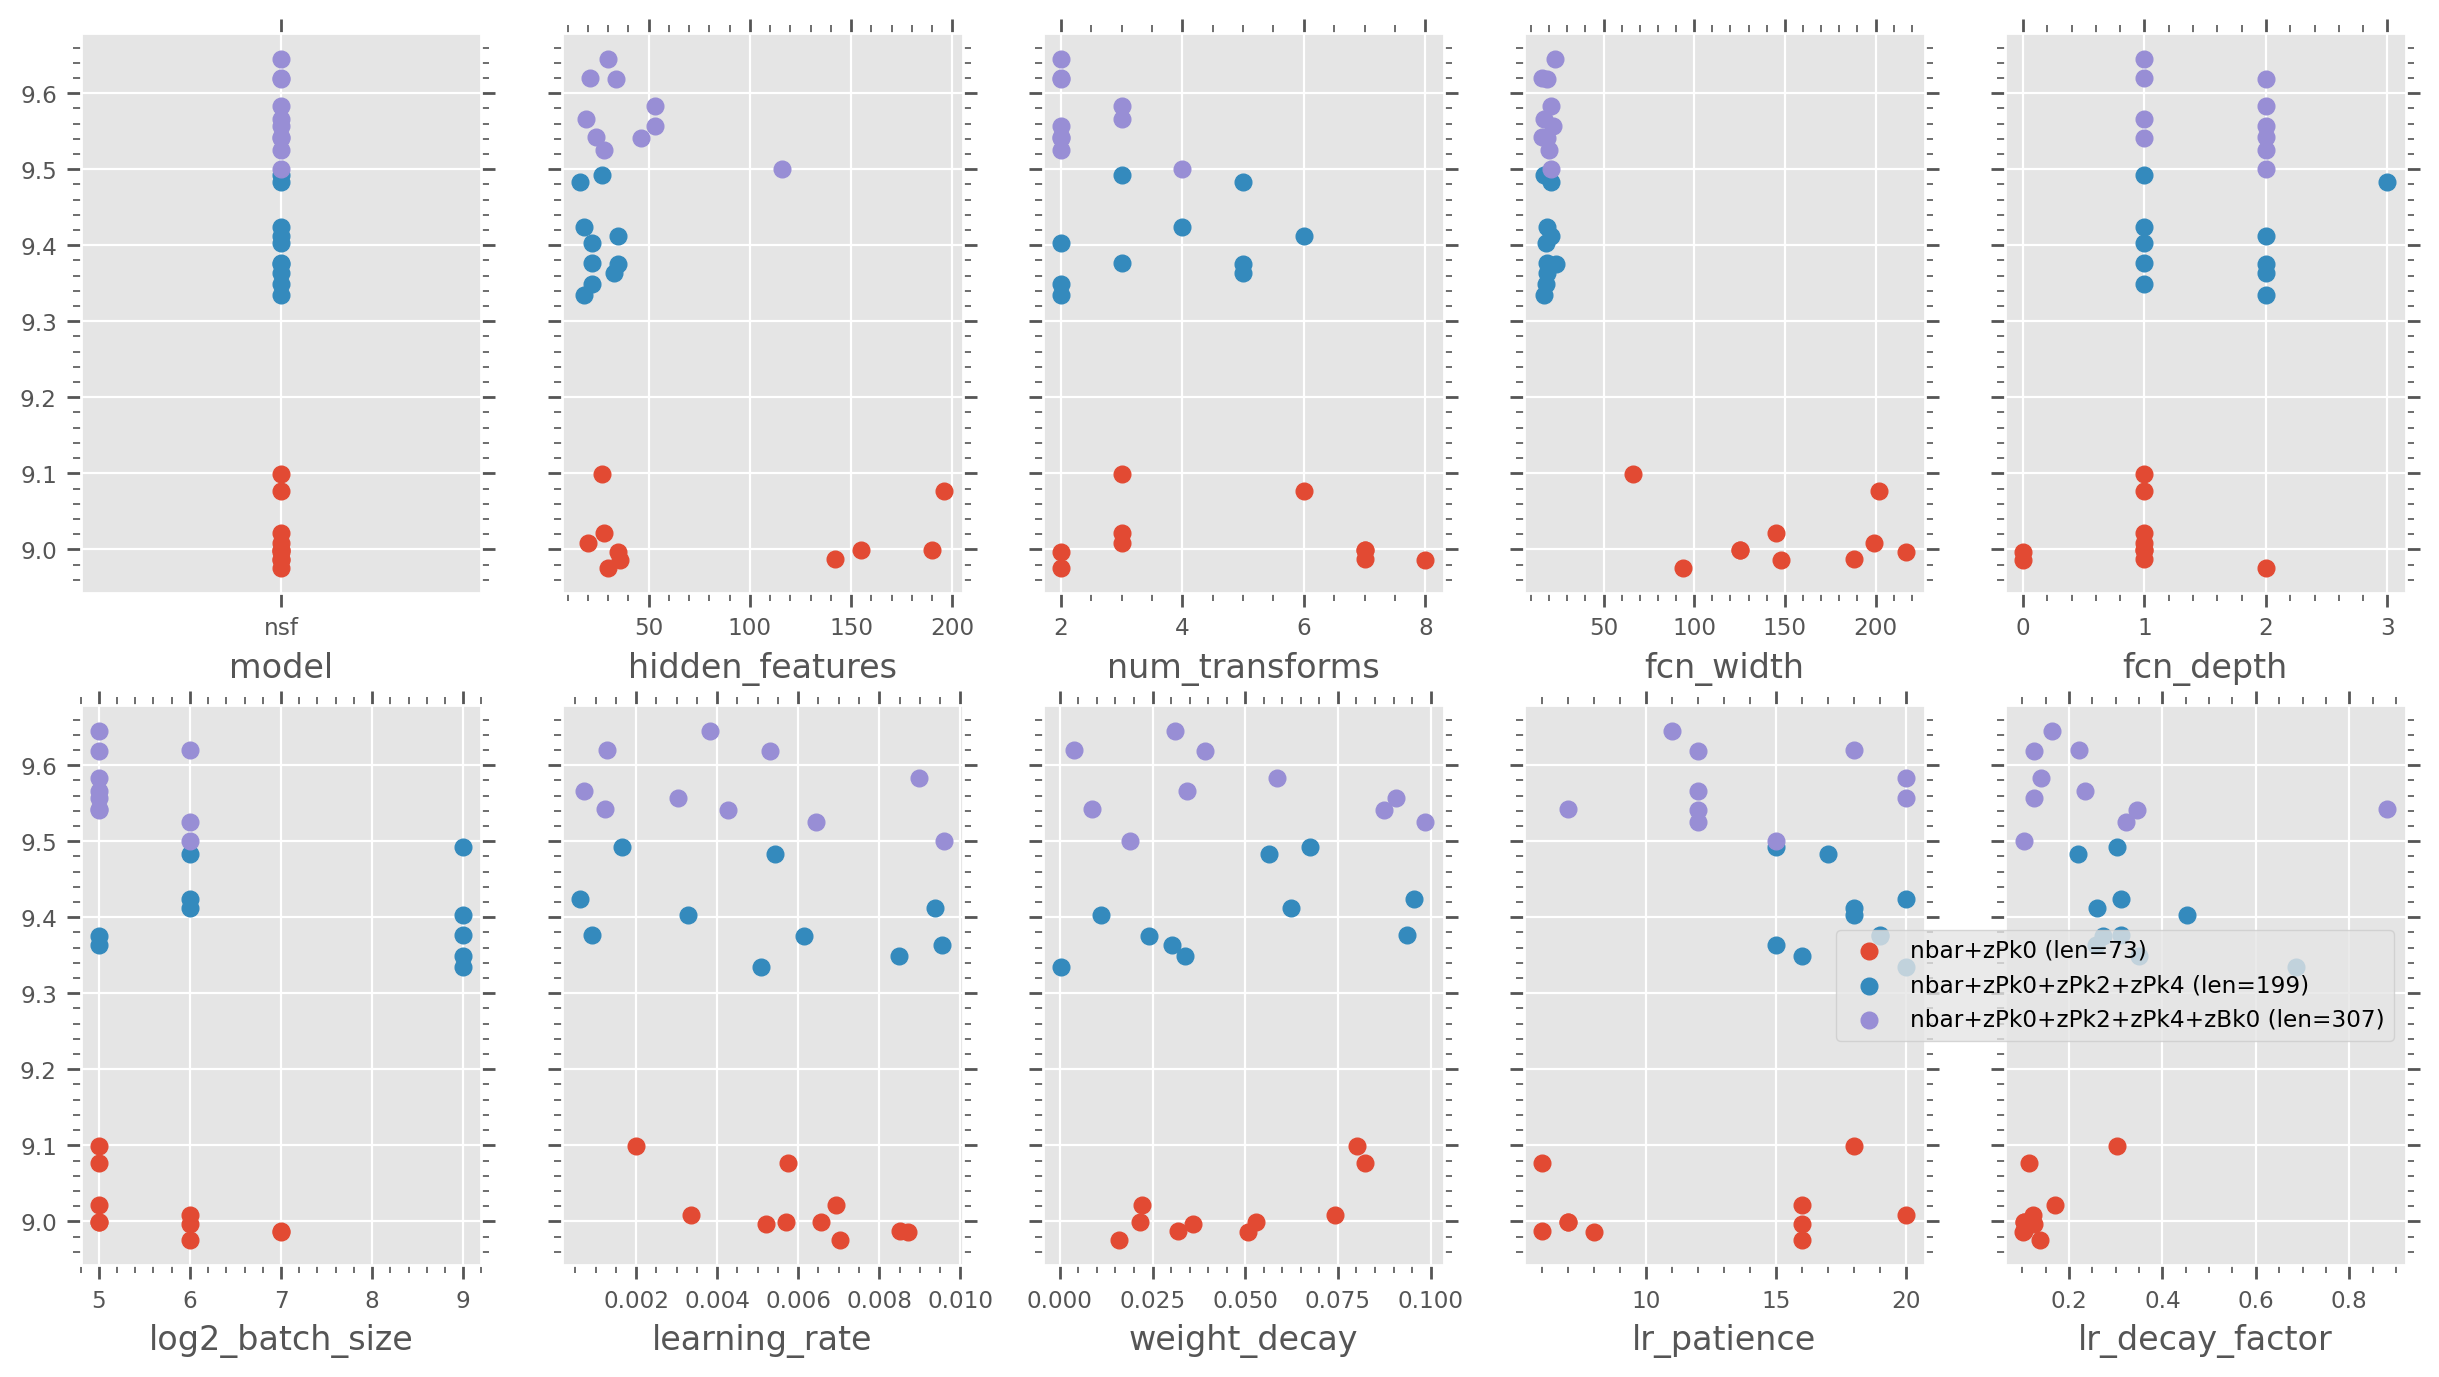

In [122]:
def plot_param_dependence(modeldir, axs, **kwargs):
    storage = f"sqlite:///{modeldir}/optuna_study.db"
    study = optuna.load_study(study_name=modeldir.split('/')[-2], storage=storage)
    trials = [t for t in study.trials if t.value is not None]
    best_trials = sorted(trials, key=lambda t: t.value, reverse=True)[:10]

    param_names = list(best_trials[0].params.keys())
    nplots = len(param_names)
    y = [t.value for t in best_trials]

    for ax, pname in zip(axs[:nplots], param_names[:nplots]):
        x = [t.params.get(pname, np.nan) for t in best_trials]
        ax.scatter(x, y, **kwargs)
        ax.set_xlabel(pname)

    for ax in axs[nplots:]:
        ax.set_visible(False)

f, axs = plt.subplots(2, 5, sharey=True, figsize=(15, 8), 
                      gridspec_kw={'hspace': 0.2})
axs = axs.flatten()
for i, m in enumerate(modeldirs):
    plot_param_dependence(m, axs, label=f"{names[i]} (len={x_len[i]})")

ax = axs[-1]
ax.legend()

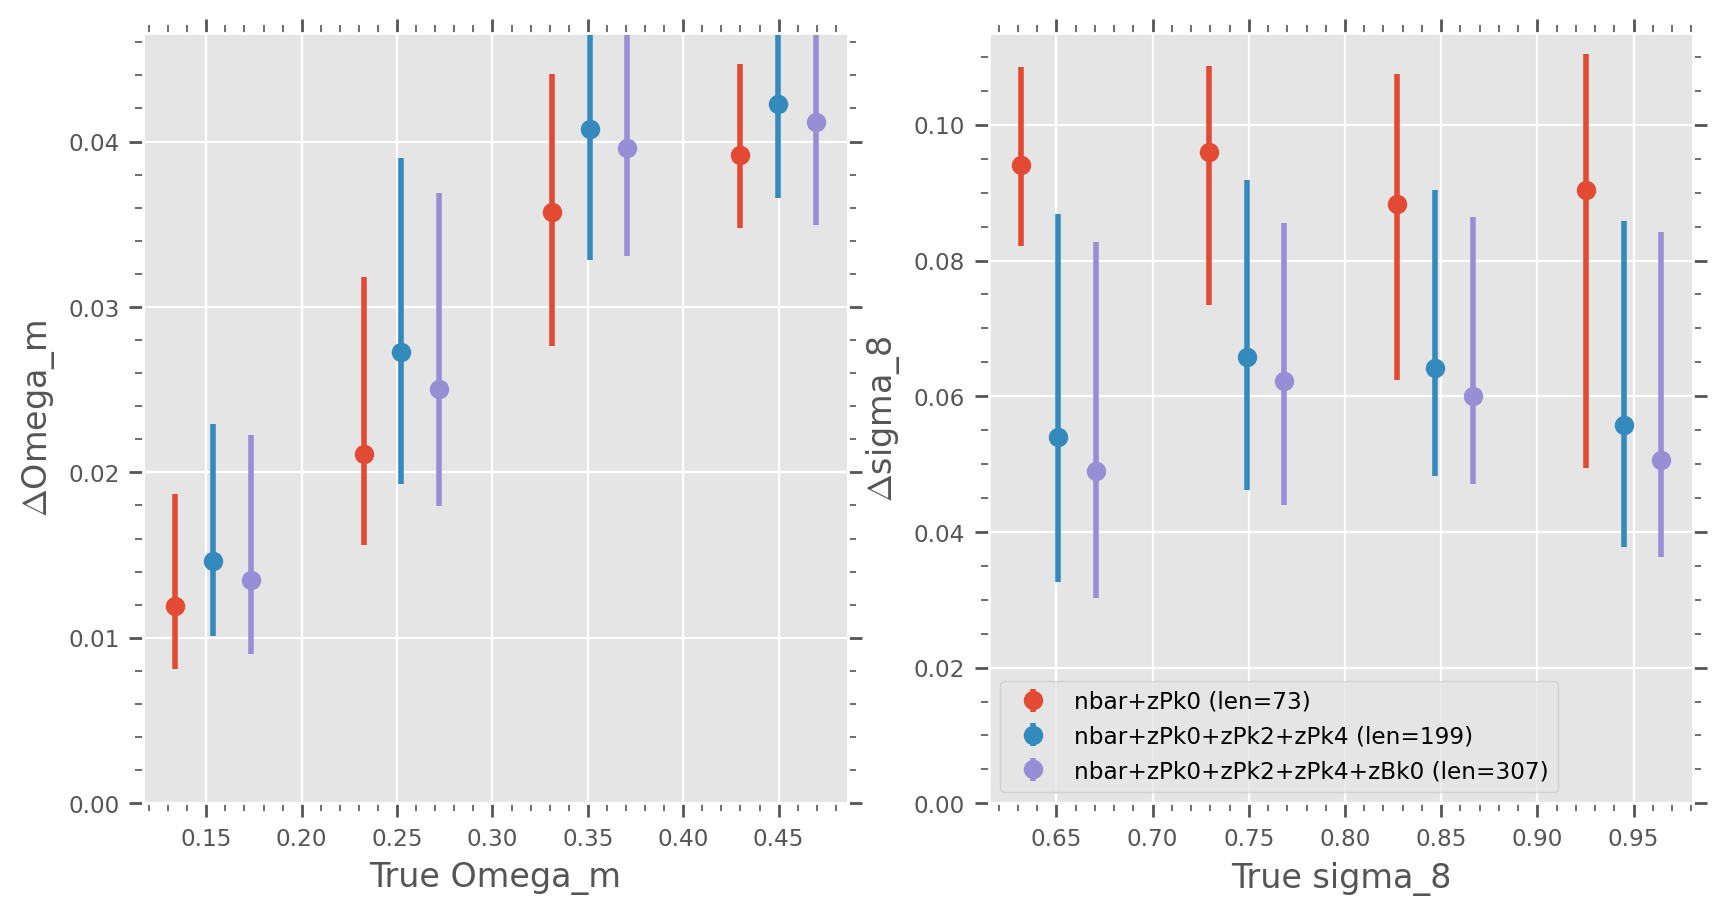

In [123]:
def plot_scatter(modeldir, axs, offset=0, **kwargs):
    samples = np.load(join(modeldir, 'posterior_samples.npy'))
    theta = np.load(join(modeldir, 'theta_test.npy'))

    stdev = samples.std(axis=0)

    Nbins = 4
    for i, (j, label) in enumerate(zip([0,4], ['Omega_m', 'sigma_8'])):
        ax = axs[i]

        minmax = theta[:, j].min(), theta[:, j].max()
        off = offset*np.diff(minmax)

        bin_edges = np.linspace(*minmax, num=Nbins+1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        y_ = []
        for k in range(Nbins):
            mask = (theta[:, j] >= bin_edges[k]) & (theta[:, j] < bin_edges[k+1])
            y_.append(np.percentile(stdev[mask,j], [50, 16, 84]))
        y_ = np.array(y_)

        ax.errorbar(bin_centers+off, y_[:, 0], 
                    yerr=[y_[:, 0] - y_[:, 1], y_[:, 2] - y_[:, 0]], 
                    fmt='o', **kwargs)
        ax.set_xlabel(f'True {label}')
        ax.set_ylabel(f'$\Delta${label}')
        ax.set_ylim(0)
    ax.legend()
f, axs = plt.subplots(1, 2, figsize=(10, 5))

for i, m in enumerate(modeldirs):
    offperc = (i-1)*0.05
    plot_scatter(m, axs, offset=offperc, label=f"{names[i]} (len={x_len[i]})")

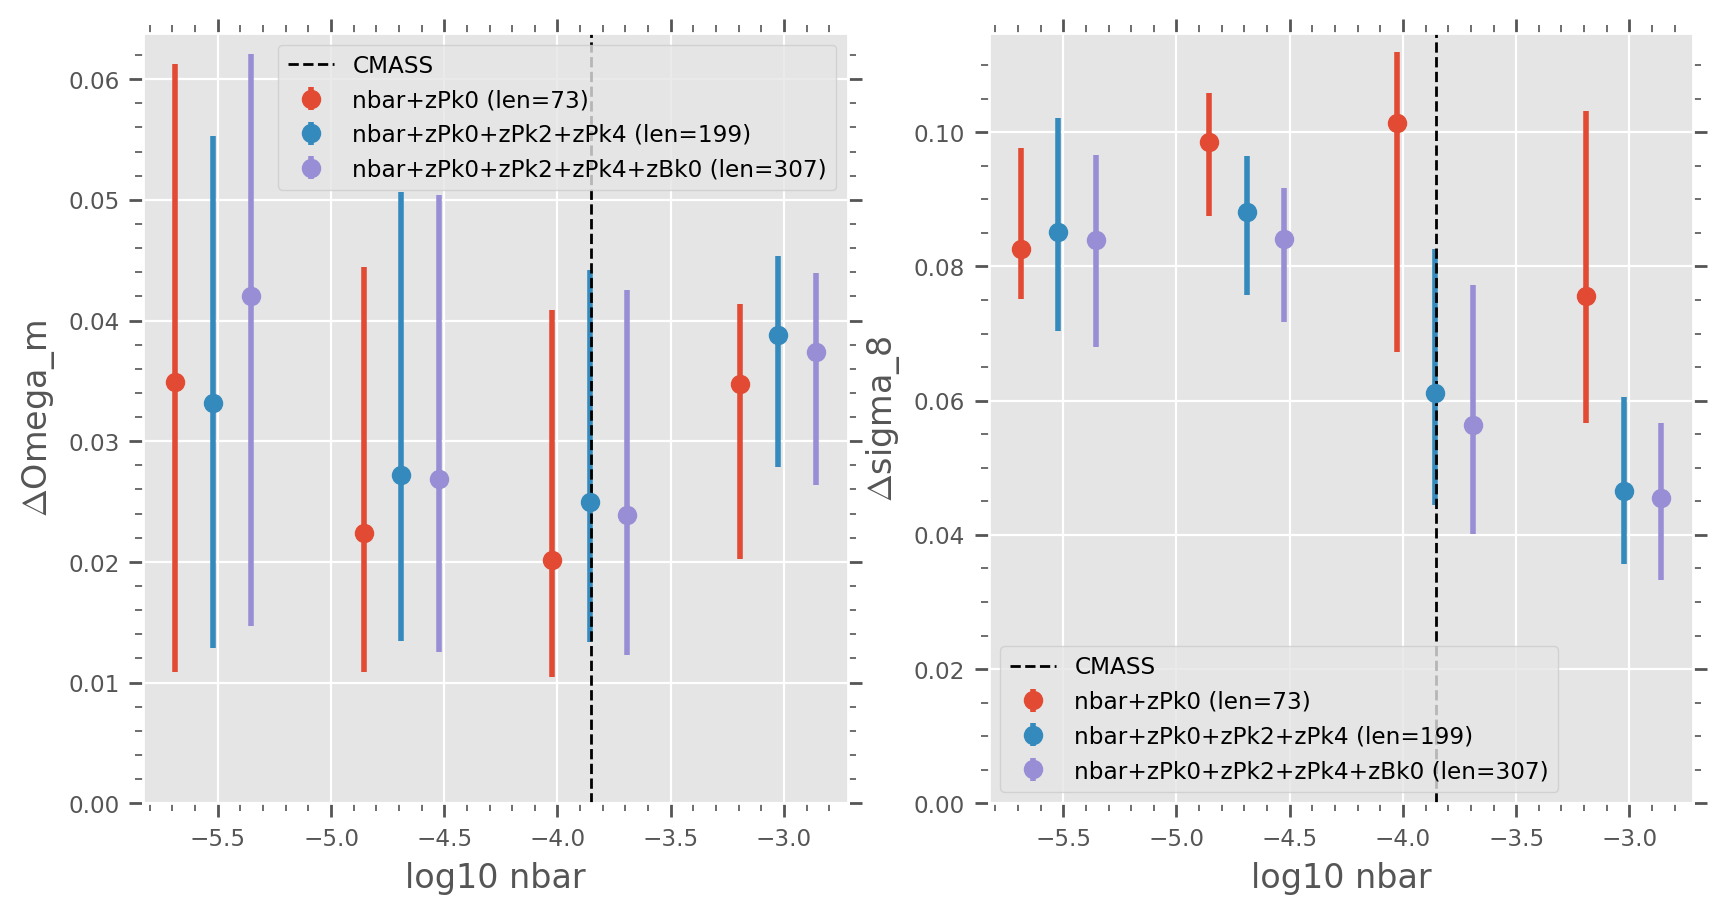

In [66]:
def plot_scatter(modeldir, ax, offset=0, **kwargs):
    samples = np.load(join(modeldir, 'posterior_samples.npy'))
    nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1]

    stdev = samples.std(axis=0)

    Nbins = 4
    for i, (j, label) in enumerate(zip([0,4], ['Omega_m', 'sigma_8'])):
        ax = axs[i]

        minmax = nbar.min(), nbar.max()
        off = offset*np.diff(minmax)

        bin_edges = np.linspace(*minmax, num=Nbins+1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        y_ = []
        for k in range(Nbins):
            mask = (nbar >= bin_edges[k]) & (nbar < bin_edges[k+1])
            y_.append(np.percentile(stdev[mask,j], [50, 16, 84]))
        y_ = np.array(y_)

        ax.errorbar(bin_centers+off, y_[:, 0], 
                    yerr=[y_[:, 0] - y_[:, 1], y_[:, 2] - y_[:, 0]], 
                    fmt='o', **kwargs)
        ax.set_xlabel(f'log10 nbar')
        ax.set_ylabel(f'$\Delta${label}')
        ax.set_ylim(0)
        
    ax.legend()
f, axs = plt.subplots(1, 2, figsize=(10, 5))

for i, m in enumerate(modeldirs):
    offperc = (i-1)*0.05
    plot_scatter(m, axs, offset=offperc, label=f"{names[i]} (len={x_len[i]})")

for ax in axs:
    ax.axvline(np.log10(1.4e-4), color='k', linestyle='--', lw=1, label='CMASS')
    ax.legend()

Found 44 samples close to fiducial for nbar+zPk0
Found 44 samples close to fiducial for nbar+zPk0+zPk2+zPk4
Found 44 samples close to fiducial for nbar+zPk0+zPk2+zPk4+zBk0


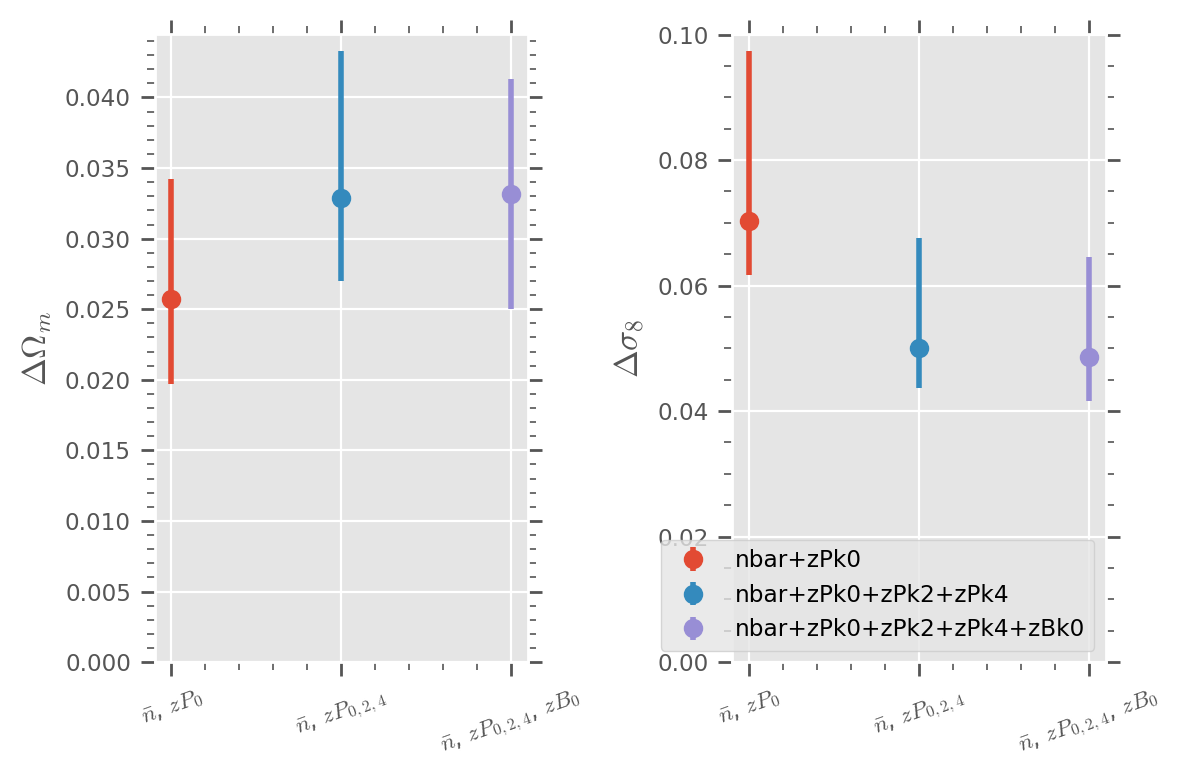

In [126]:
thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])
names = [r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8']

def plot_model_stdev(modeldir, x_idx, axs, **kwargs):
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        return False

    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))
    
    # Check if x_test exists, otherwise assume nbar logic is handled elsewhere or adapt as needed
    nbar = np.load(join(modeldir, 'x_test.npy'))[:, -1] 

    mask = np.all(np.isclose(theta[:, [0, 4]], thetafid[[0, 4]], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    
    if np.sum(mask) == 0:
        return False

    # Keep only samples close to fiducial
    filtered_samples = samples[:, mask]
    print(f'Found {np.sum(mask)} samples close to fiducial for {s}')
    stdev = np.std(filtered_samples, axis=0)

    for j, i in enumerate([0, 4]):
        ax = axs[j]
        
        # Calculate percentiles across the surviving test points for this model
        param_stdevs = stdev[:, i]
        perc = np.percentile(param_stdevs, [50, 16, 84])
        
        ax.errorbar(
            x_idx, perc[0],
            yerr=[[perc[0] - perc[1]], [perc[2] - perc[0]]],
            fmt='o', **kwargs
        )
        ax.set_ylabel(f'$\Delta {names[i]}$')
        
    return True


f, axs = plt.subplots(1, 2, figsize=(6, 4), sharex=True)
axs = axs.flatten()

labels = sorted(os.listdir(parentdir))
valid_labels = []
x_idx = 0

for s in labels:
    modeldir = join(parentdir, s, postfix)
    
    # Plot the point at the current x_idx. If data exists, advance the index and save the label.
    if plot_model_stdev(modeldir, x_idx, axs, label=s):
        valid_labels.append(s)
        x_idx += 1

# Apply the categorical x-axis formatting from Cell 1
for ax in axs:
    ax.set_xticks(range(len(valid_labels)))
    ax.set_xticklabels(simple(valid_labels), rotation=20)
    ax.set_ylim(0, None)
ax.legend(loc='lower right')

plt.tight_layout()

In [ ]:


parentdir = join(wdir, nbody, sim, 'models', tracer)

thetafid = np.array([0.3, 0.5, 0.7, 1.0, 0.8])

stdev = {}
studies = []
for s in os.listdir(parentdir):
    print(s)
    modeldir = join(parentdir, s, postfix)
    filepath = join(modeldir, 'posterior_samples.npy')
    if not exists(filepath):
        print('Missing samples. Skipping...')
        continue
    samples = np.load(filepath)
    theta = np.load(join(modeldir, 'theta_test.npy'))

    # Find indices where theta[:, :5] is close to thetafid
    mask = np.all(np.isclose(
        theta[:, [0, 4]], thetafid[[0, 4]], rtol=0.1), axis=1)
    mask &= (nbar > np.log10(1.4e-4))
    print(f'Found {np.sum(mask)} samples close to fiducial')

    # Keep only those samples
    samples = samples[:, mask]

    stdev[s] = np.std(samples, axis=0)


    filepath = join(modeldir, 'optuna_study.db')

    # Load the 'summaries' study from the database
    storage = f"sqlite:///{filepath}"
    study = optuna.load_study(study_name=s, storage=storage)
    studies.append(study)

labels = sorted(list(stdev.keys()))

f, axs = plt.subplots(1,2, figsize=(6,4), sharex=True)
axs = axs.flatten()

names = [
    r'\Omega_m', r'\Omega_b', r'h', r'n_s', r'\sigma_8'
]

for j, i in enumerate([0, 4]):
    ax = axs[j]
    stdevs = [stdev[label][:, i] for label in labels]
    percentiles = np.percentile(stdevs, [50, 16, 84], axis=1)
    ax.errorbar(
        simple(labels), percentiles[0],
        yerr=[percentiles[0]-percentiles[1], percentiles[2]-percentiles[0]],
        fmt='o')
    ax.set_ylim(0)
    ax.set_ylabel(f'$\Delta {names[i]}$')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(simple(labels), rotation=20)

# axs[5].axis('off')
# axs[0].set_title('w/ BFast Bispectrum')
plt.tight_layout()

Text(0.5, 1.0, 'Pk0+noise fastpm_4k_npca')

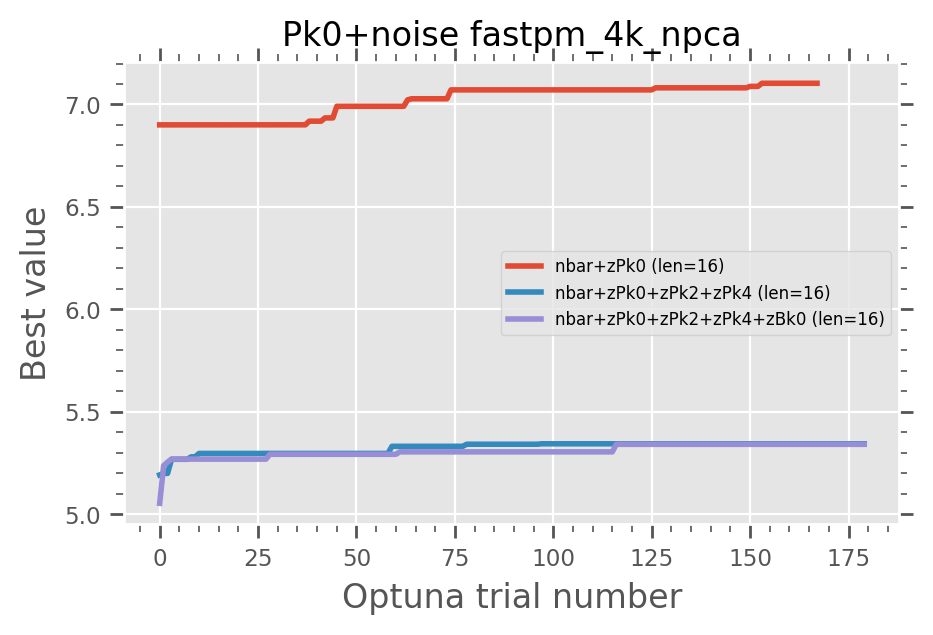

In [84]:
sim = 'fastpm_4k_npca'
modeldirs = [
    f'/anvil/scratch/x-mho1/cmass-ili/quijotelike/{sim}/models/galaxy/nbar+zPk0/kmin-0.0_kmax-0.4',
    f'/anvil/scratch/x-mho1/cmass-ili/quijotelike/{sim}/models/galaxy/nbar+zPk0+zPk2+zPk4/kmin-0.0_kmax-0.4',
    f'/anvil/scratch/x-mho1/cmass-ili/quijotelike/{sim}/models/galaxy/nbar+zPk0+zPk2+zPk4+zBk0/kmin-0.0_kmax-0.4',
]

names = [
    m.split('/')[-2] for m in modeldirs
]

x_len = []
for m in modeldirs:
    x_ = np.load(join(m, 'x_test.npy'))
    x_len.append(x_.shape[-1])

def plot_history(modeldir, ax, **kwargs):
    storage = f"sqlite:///{modeldir}/optuna_study.db"
    study = optuna.load_study(study_name=modeldir.split('/')[-2], storage=storage)
    trials = study.trials
    trial_numbers = [t.number for t in trials if t.value is not None]
    values = [t.value for t in trials if t.value is not None]
    
    best_values = np.maximum.accumulate(values)
    
    ax.plot(trial_numbers, best_values, **kwargs)

f, ax = plt.subplots(figsize=(5, 3))
for i, m in enumerate(modeldirs):
    plot_history(m, ax, label=f"{names[i]} (len={x_len[i]})")

ax.legend(fontsize=6) # , loc='lower right')
ax.set(xlabel='Optuna trial number', ylabel='Best value')
ax.set_title(f'Pk0+noise {sim}', fontsize=12)